In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

llm_model = ChatGroq(
temperature=0.5,
model="llama-3.1-8b-instant",
api_key=groq_api_key
)

In [3]:
#create a typed dict for the state
class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    evaluation: int

In [4]:
def create_outline(state: BlogState)-> BlogState:
    #extract the title
    title = state['title']

    #form the prompt
    prompt = f"""Generate a detailed outline for a blog post on the title: {title}. The outline should have at least 5 sections with 2-3 bullet points each."""

    #call the 1lm model
    outline = llm_model.invoke(prompt).content

    #update the state
    state['outline'] = outline

    return state


def create_blog(state: BlogState) -> BlogState:
    #extract the outline
    title = state['title']
    outline = state['outline']

    #form the prompt
    prompt = f"Write a detailed blog post on the title {title} using the following outline:\n{outline}"

    #call the lim model
    blog_post = llm_model.invoke(prompt).content

    #update the state
    state['content'] = blog_post

    return state


def evaluate_blog(state: BlogState) -> BlogState:
    #extract the blog content
    outline = state['outline']

    blog_content = state['content']

    # form the prompt
    prompt = f"""Based on the following outline:\n{outline}\n rate the following blog post :\n[blog_content). And generate the score in integer form like as 1,2,3..10. Provide only the numeric score.""" 

    # prompt = f"""Based on the following outline: \n{outline}\nEvaluate the following blog post on a scale of 1 to 10 based on its clarity, depth, and engagement: \n{blog_content). Provide only the numeric score."""

    #call the 11m model
    evaluation = llm_model.invoke(prompt).content

    #update the state
    state['evaluation'] = int(evaluation.strip())

    return state

In [5]:
#create a graph
graph = StateGraph(BlogState)

#add the nodes
graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)
graph.add_node("evaluate_blog", evaluate_blog)

#add the edges
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", "evaluate_blog")
graph.add_edge("evaluate_blog", END)

#compile the graph
workflow = graph.compile()

In [6]:
#execute the graph
initial_state = {"title": "Traveling to Japan: A Comprehensive Guide"}
final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Traveling to Japan: A Comprehensive Guide', 'outline': '**Traveling to Japan: A Comprehensive Guide**\n\n**I. Planning Your Trip to Japan**\n\n* **When to Visit:** Japan has four distinct seasons, each with its unique charm. Spring (March to May) is ideal for cherry blossom viewing, while autumn (September to November) is perfect for foliage. Summer (June to August) is hot and humid, while winter (December to February) is cold, especially in the north.\n* **Best Time to Visit Popular Destinations:** Tokyo, Kyoto, and Osaka are popular destinations, but they can get crowded during peak travel seasons. Consider visiting during the shoulder season (April to May or September to November) for smaller crowds and lower prices.\n* **Visa Requirements:** Citizens of many countries can enter Japan without a visa for up to 90 days. Check the Japanese government\'s website for visa requirements and application procedures.\n\n**II. Getting Around Japan**\n\n* **Transportation Options:** 

In [7]:
print(final_state["outline"])

**Traveling to Japan: A Comprehensive Guide**

**I. Planning Your Trip to Japan**

* **When to Visit:** Japan has four distinct seasons, each with its unique charm. Spring (March to May) is ideal for cherry blossom viewing, while autumn (September to November) is perfect for foliage. Summer (June to August) is hot and humid, while winter (December to February) is cold, especially in the north.
* **Best Time to Visit Popular Destinations:** Tokyo, Kyoto, and Osaka are popular destinations, but they can get crowded during peak travel seasons. Consider visiting during the shoulder season (April to May or September to November) for smaller crowds and lower prices.
* **Visa Requirements:** Citizens of many countries can enter Japan without a visa for up to 90 days. Check the Japanese government's website for visa requirements and application procedures.

**II. Getting Around Japan**

* **Transportation Options:** Japan has an extensive public transportation system, including trains, buses, 

In [8]:
print(final_state["content"])

**Traveling to Japan: A Comprehensive Guide**

Japan, a country steeped in tradition and modernity, is a destination that has captivated the hearts of travelers from around the world. From the vibrant streets of Tokyo to the serene gardens of Kyoto, Japan offers a unique and unforgettable experience. However, planning a trip to Japan can be overwhelming, especially for first-time visitors. In this comprehensive guide, we will walk you through the essential steps to plan your trip, navigate the country, and make the most of your time in Japan.

**I. Planning Your Trip to Japan**

Before you embark on your journey, it's essential to plan your trip carefully. Japan has four distinct seasons, each with its unique charm.

### **When to Visit:**

* **Spring (March to May):** Cherry blossom viewing is a highlight of spring in Japan. The country is painted with vibrant pink and white hues as the iconic sakura trees bloom. This season is ideal for visiting popular destinations like Tokyo, Kyoto

In [9]:
print(final_state["evaluation"])

7


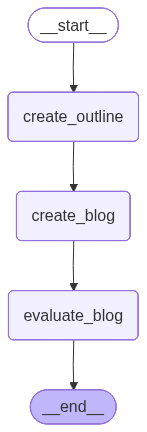

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())